In [1]:
import os
import random
import h5py
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [6]:
with h5py.File('C:/datasets/imagenet_v4_rot_10m_5percent_subset.h5') as h5:
    print(h5.keys())
    for k in h5.keys():
        print(k)
        labels = h5[k]['labels'][:]

<KeysViewHDF5 ['test', 'train', 'valid']>
test
train
valid


In [7]:
labels.shape

(100000,)

In [8]:
labels

array([10,  0, 13, ..., 12,  9,  4], dtype=uint8)

In [ ]:
for l in labels:
    print(l)

In [2]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
sym_dict = {}
for i, sym in enumerate(symmetry_classes):
    sym_dict[i] = sym
sym_dict

{0: 'p1',
 1: 'p2',
 2: 'pm',
 3: 'pg',
 4: 'cm',
 5: 'pmm',
 6: 'pmg',
 7: 'pgg',
 8: 'cmm',
 9: 'p4',
 10: 'p4m',
 11: 'p4g',
 12: 'p3',
 13: 'p3m1',
 14: 'p31m',
 15: 'p6',
 16: 'p6m'}

In [5]:
l1_dict = {'p1': 0, 'p2': 1, 'pm': 0, 'pg': 0, 'cm': 0, 'pmm': 1, 'pmg': 1, 'pgg': 1, 'cmm': 1, 'p4': 1, 'p4m': 1, 'p4g': 1, 'p3': 2, 'p3m1': 2, 'p31m': 2, 'p6': 2, 'p6m': 2}
with h5py.File('../../../../imagenet_v4_rot_10m_5percent_subset_hierarchy.h5', 'a') as h5:
    for k in h5.keys():
        print(k)
        labels = h5[k]['labels'][:]
        h5[k].create_dataset('l1_labels', data=np.array([l1_dict[sym_dict[l]] for l in labels]))

test
train
valid


In [6]:
with h5py.File('../../../../imagenet_v4_rot_10m_5percent_subset_hierarchy.h5', 'r') as h5:
    for k in h5.keys():
        print(k)
        print(h5[k]['l1_labels'][:])

test
[1 2 2 ... 1 1 0]
train
[1 2 1 ... 1 2 2]
valid
[1 0 2 ... 2 1 0]


In [14]:
import os
from tqdm import tqdm
import wandb
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets, models

import sys
sys.path.append('../../../helper_functions/')
from visualization_functions import show_images

sys.path.append('../src/')
from h5_functions import list_to_dict, viz_dataloader

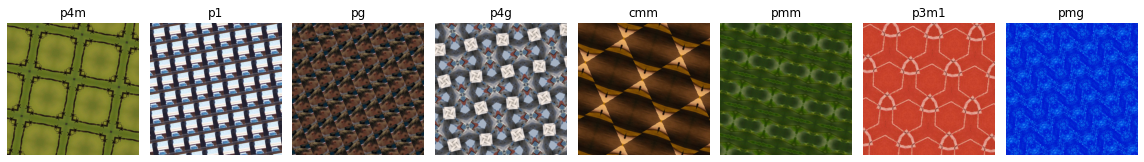

In [15]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

train_ds = hdf5_dataset('/scratch/yichen/imagenet_v4_rot_10m_5percent_subset_hierarchy.h5', folder='train', transform=transforms.ToTensor())
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=4)
viz_dataloader(train_dl, label_converter=label_converter, label_idx=1)

In [ ]:
class hdf5_dataset(Dataset):
    
    def __init__(self, file_path, folder='train', transform=None, classes=[]):
        self.file_path = file_path
        self.folder = folder
        self.transform = transform
        self.hf = None

    def __len__(self):
        with h5py.File(self.file_path, 'r') as f:
            self.len = len(f[self.folder]['labels'])
        return self.len
    
    def __getitem__(self, idx):
        if self.hf is None:
            self.hf = h5py.File(self.file_path, 'r')
        
        image = np.array(self.hf[self.folder]['data'][idx])
        labels = np.array(self.hf[self.folder]['labels'][idx])
        labels_l1 = np.array(self.hf[self.folder]['l1_labels'][idx])
        
        if self.transform:
            image = self.transform(image)
        return image, labels, labels_l1

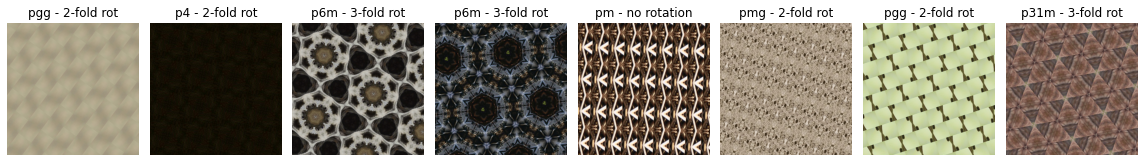

In [17]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

label_converter2 = {0:'no rotation', 1:'2-fold rot', 2:'3-fold rot'}

ds = hdf5_dataset('/scratch/yichen/imagenet_v4_rot_10m_5percent_subset_hierarchy.h5', folder='train', transform=transforms.ToTensor())
dl = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=4)

n = 8
batch = next(iter(dl))
if len(batch[0]) < n: 
    raise ValueError("n is smaller than batch size, increase n")
inputs = batch[0][:n]
labels = list(batch[1][:n].numpy())
labels_l1 = list(batch[2][:n].numpy())

for i in range(len(labels)):
    labels[i] = label_converter[labels[i]]

for i in range(len(labels)):
    labels[i] += ' - '
    labels[i] += label_converter2[labels_l1[i]]

show_images(torch.permute(inputs, [0,2,3,1]).cpu().numpy(), labels=labels, hist_bins=100)  

In [4]:
l1_dict = {'p1': 0, 'p2': 1, 'pm': 0, 'pg': 0, 'cm': 0, 'pmm': 1, 'pmg': 1, 'pgg': 1, 'cmm': 1, 'p4': 1, 'p4m': 1, 'p4g': 1, 'p3': 2, 'p3m1': 2, 'p31m': 2, 'p6': 2, 'p6m': 2}
l2_dict = {'p1': 0, 'p2': 0, 'pm': 1, 'pg': 0, 'cm': 1, 'pmm': 1, 'pmg': 1, 'pgg': 0, 'cmm': 1, 'p4': 1, 'p4m': 1, 'p4g': 1, 'p3': 0, 'p3m1': 0, 'p31m': 0, 'p6': 1, 'p6m': 1}
l3_dict = {'p1': 0, 'p2': 0, 'pm': 1, 'pg': 0, 'cm': 1, 'pmm': 1, 'pmg': 1, 'pgg': 0, 'cmm': 1, 'p4': 1, 'p4m': 1, 'p4g': 1, 'p3': 0, 'p3m1': 0, 'p31m': 0, 'p6': 1, 'p6m': 1}


# Step 2: Create a list of numbers
numbers = [1, 2, 3, 2, 1]

# Step 3: Use map and lambda to convert numbers to strings
strings = list(map(lambda num: sym_dict[num], numbers))

# 'strings' now contains the converted strings
print(strings)

['p2', 'pm', 'pg', 'pm', 'p2']


In [35]:
file_list = glob.glob('d:/from_nhi/generation_images_selected_01102022/*')
filelist = random.shuffle(file_list)
with h5py.File('d:/from_nhi/generation_images_selected_01102022.h5', 'a') as h5:
    imgs = []
    for i, file in enumerate(file_list):
        image = Image.open(file)

        if np.array(image).shape != (256, 256, 3):
            image = image.resize((256, 256))
        else:
            print(np.array(image).shape)

        imgs.append(np.array(image)[:,:,:3])
    imgs = np.array(imgs)
    print(imgs.shape)
    h5.create_dataset('images', data=imgs, dtype='uint8')

(9024, 256, 256, 3)


(9024, 256, 256, 3)


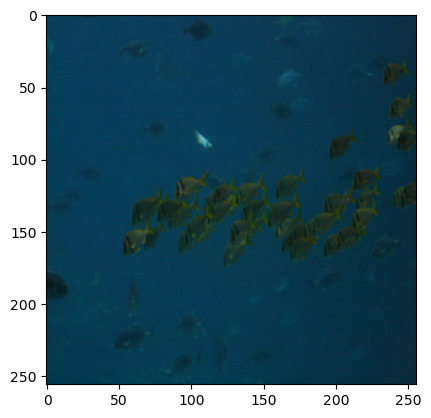

In [37]:
with h5py.File('d:/from_nhi/generation_images_selected_01102022.h5', 'r') as h5:
    print(h5['images'].shape)
    plt.imshow(h5['images'][20])
    plt.show()

In [13]:
import sys
sys.path.append('c:/Users/yig319/Dropbox (LU Student)/helper_functions/')
from visualization_functions import *

IndexError: index 13 is out of bounds for axis 0 with size 13

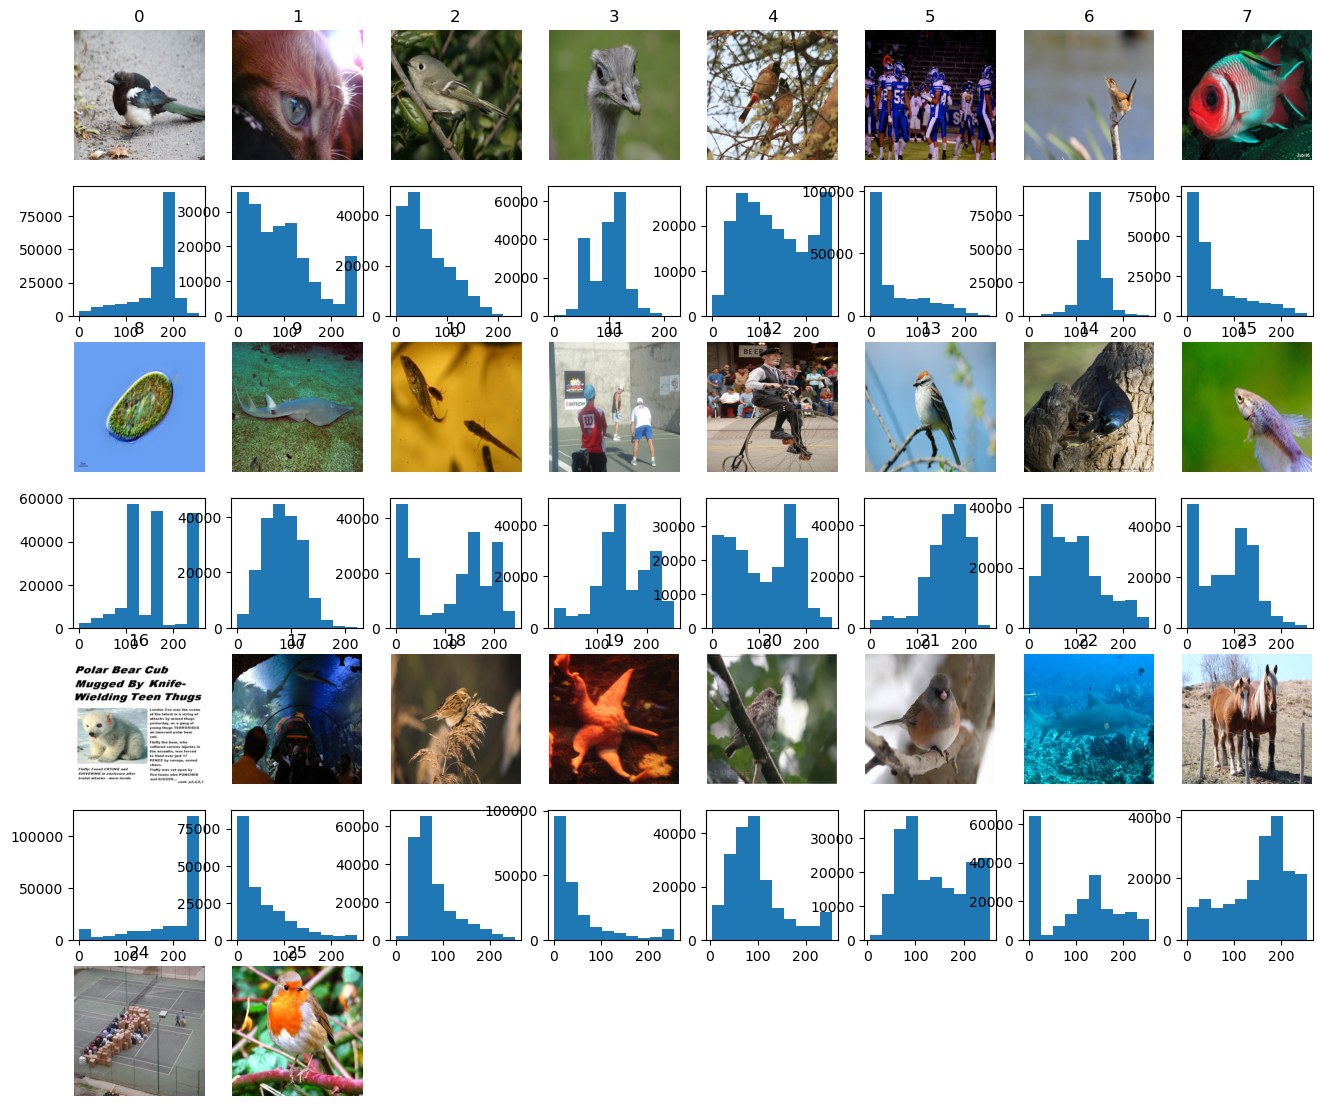

In [14]:
with h5py.File('d:/from_nhi/generation_images_selected_01102022.h5', 'r') as h5:
    index_list = random.choices(range(0, len(h5['images'])), k=50)
    index_list = np.sort(index_list)
    imgs = h5['images'][index_list]
show_images(imgs, hist_bins=10)

In [34]:
len(imgs)
for img in imgs:
    if img.shape != (256, 256, 3):
        a
        print(img.shape)


(256, 256, 4)
(256, 256, 4)
(256, 256, 4)


In [32]:
imgs = np.array(imgs)

C:\Users\yig319\AppData\Local\Temp\ipykernel_30392\1041896984.py:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  imgs = np.array(imgs)


ValueError: could not broadcast input array from shape (256,256,3) into shape (256,256)